In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [23]:
capture = cv2.VideoCapture(r'D:\Route_AI\Sessions_DL\Session_15_CV\Project3_ObjectDetection\Copy of vtest.avi')

In [24]:
def convert_color(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

In [25]:
capture.read()

(True,
 array([[[104, 142, 177],
         [105, 143, 178],
         [105, 143, 178],
         ...,
         [ 57,  83, 107],
         [ 70,  80, 106],
         [ 41,  51,  77]],
 
        [[105, 143, 178],
         [105, 143, 178],
         [105, 143, 178],
         ...,
         [ 55,  81, 105],
         [ 71,  81, 107],
         [ 44,  54,  80]],
 
        [[105, 143, 178],
         [105, 143, 178],
         [105, 143, 178],
         ...,
         [ 51,  76, 102],
         [ 73,  84, 107],
         [ 49,  60,  83]],
 
        ...,
 
        [[  0,  35,  20],
         [  0,  35,  20],
         [  0,  36,  21],
         ...,
         [  9,  72,  60],
         [ 11,  74,  62],
         [ 11,  74,  62]],
 
        [[  0,  35,  20],
         [  0,  35,  20],
         [  0,  36,  21],
         ...,
         [  8,  71,  59],
         [  9,  72,  60],
         [ 11,  74,  62]],
 
        [[  0,  35,  20],
         [  0,  35,  20],
         [  0,  36,  21],
         ...,
         [  9,  72,  

In [26]:
capture.get(cv2.CAP_PROP_FRAME_COUNT)

795.0

In [27]:
random_frames = capture.get(cv2.CAP_PROP_FRAME_COUNT)*np.random.uniform(size=30)

In [28]:
frames = []
for frame_id in random_frames:
    capture.set(cv2.CAP_PROP_POS_FRAMES, frame_id)
    ret, frame = capture.read()
    frames.append(frame)

capture.release()


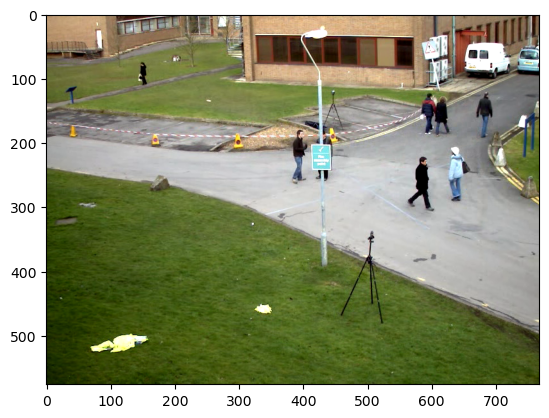

In [30]:
plt.imshow(convert_color(frames[0]))

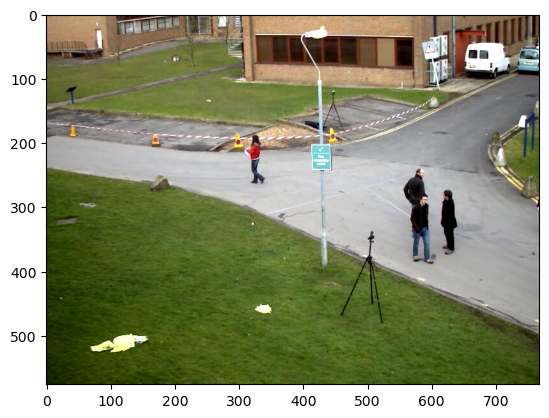

In [31]:
plt.imshow(convert_color(frames[10]))

In [32]:
avg_frame = np.average(frames,axis=0).astype(np.uint8)

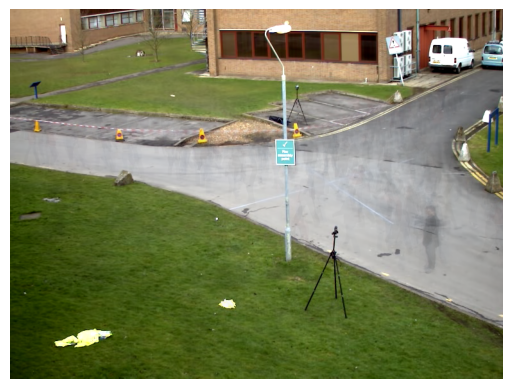

In [34]:
plt.imshow(convert_color(avg_frame))
plt.axis('off')
plt.show()

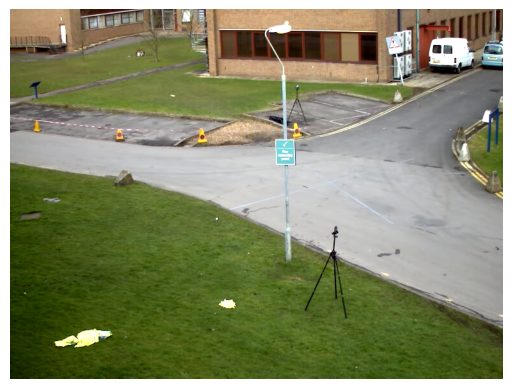

In [35]:
median_frame = np.median(frames,axis=0).astype(np.uint8)
plt.imshow(convert_color(median_frame))
plt.axis('off')
plt.show()

(-0.5, 767.5, 575.5, -0.5)

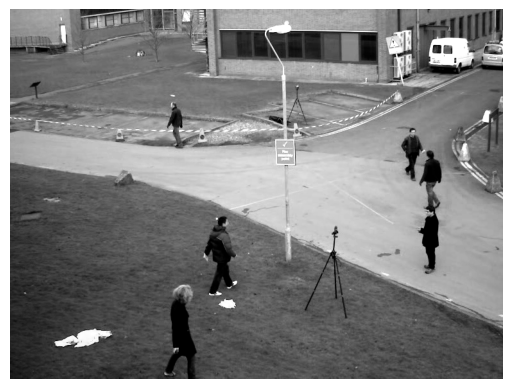

In [36]:
framex = frames[29]
gray_frame = cv2.cvtColor(framex, cv2.COLOR_BGR2GRAY)
plt.imshow(gray_frame, cmap='gray')
plt.axis('off')


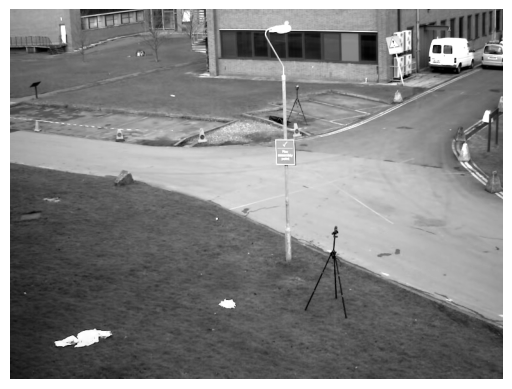

In [37]:
background = np.median(frames,axis=0).astype(np.uint8)
background_gray = cv2.cvtColor(background, cv2.COLOR_BGR2GRAY)
plt.imshow(background_gray, cmap='gray')
plt.axis('off')
plt.show()

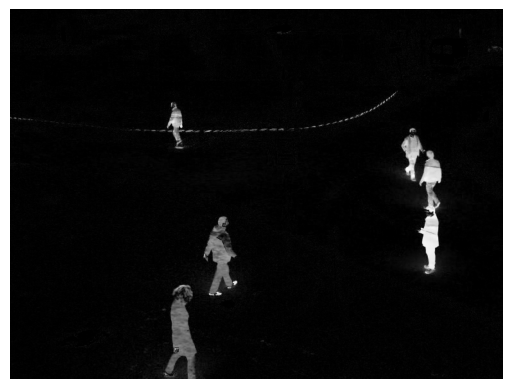

In [38]:
background_remove = cv2.absdiff(gray_frame, background_gray)
plt.imshow(background_remove, cmap='gray')
plt.axis('off') 
plt.show()

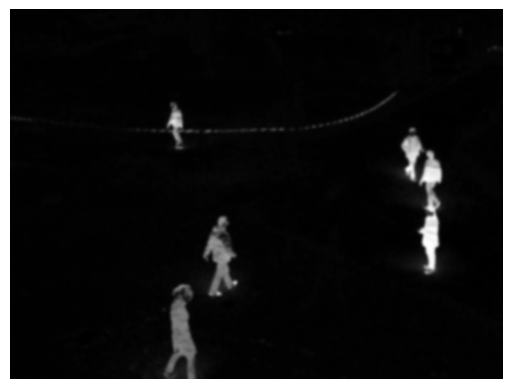

In [40]:
background_remove_blur = cv2.GaussianBlur(background_remove, (11, 11), 0)
plt.imshow(background_remove_blur, cmap='gray')
plt.axis('off')
plt.show()

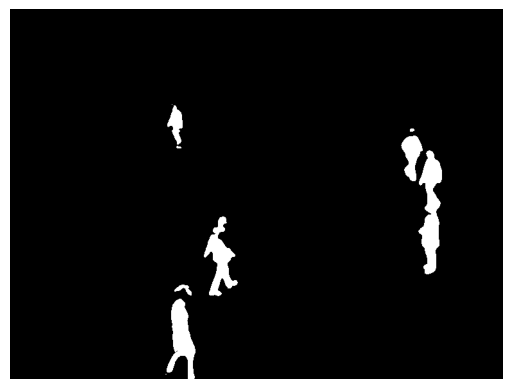

In [41]:
_ , frame_tr = cv2.threshold(background_remove_blur, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
plt.imshow(frame_tr, cmap='gray')
plt.axis('off')
plt.show()

In [42]:
contours, _ = cv2.findContours(frame_tr, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

In [43]:
len(contours)

10

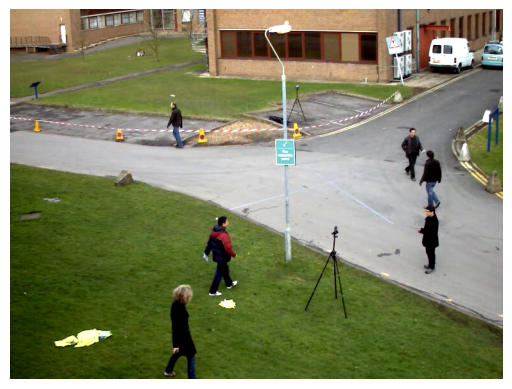

In [46]:
plt.imshow(convert_color(framex))
plt.axis('off')
plt.show()

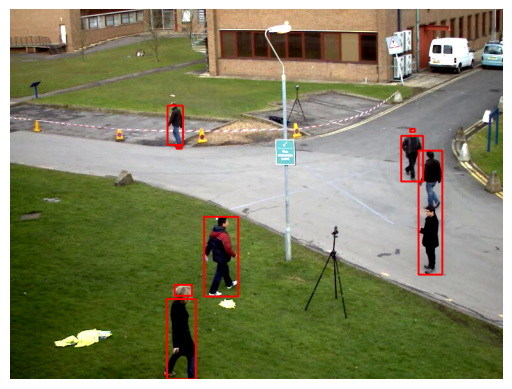

In [49]:
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    cv2.rectangle(framex, (x, y), (x + w, y + h), (0, 0, 255), 2)

plt.imshow(convert_color(framex))
plt.axis('off')
plt.show()

In [3]:
capture = cv2.VideoCapture(r'D:\Route_AI\Sessions_DL\Session_15_CV\Project3_ObjectDetection\Copy of vtest.avi')

In [ ]:
background_subtractor = cv2.createBackgroundSubtractorMOG2()
capture = cv2.VideoCapture(r'D:\Route_AI\Sessions_DL\Session_15_CV\Project3_ObjectDetection\Copy of vtest.avi')

while capture.isOpened():
    ret, frame = capture.read()
    if not ret:
        break
    fg_mask = background_subtractor.apply(frame)
    contours, _ = cv2.findContours(fg_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    for contour in contours:
        if cv2.contourArea(contour) > 500:
            x, y, w, h = cv2.boundingRect(contour)
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 0, 255), 2)
    

    cv2.imshow('Frame', frame)
    cv2.imshow('Foreground Mask', fg_mask)

    if cv2.waitKey(30) & 0xFF == ord('q'):
        break
capture.release()
cv2.destroyAllWindows()

In [ ]:
file = st.file_uploader('Upload Video',type=['mp4','avi'])
og_vid , out1_vid , out2_vid  = st.columns(3)

with og_vid:
    st.header('Original Video')
    st.video(file)
with out1_vid:
    st.header('Foreground Mask')
    st.video(output[1])

with out2_vid:
   st.header('Object Tracking')
   st.video(output[0])

In [ ]:
import numpy as np
import cv2
import streamlit as st
import tempfile


st.title('Welcom to our Project')
st.subheader('Object Tracking using OpenCV')

file = st.file_uploader("Upload Video", type=["mp4", "avi"])

if file is not None:
    tfile = tempfile.NamedTemporaryFile(delete=False)
    tfile.write(file.read())

    background_subtractor = cv2.createBackgroundSubtractorMOG2()
    capture = cv2.VideoCapture(tfile.name)
    col1, col2, col3 = st.columns(3)

    with col1:
        st.subheader("Original Video")
        frame_ph = st.empty()
        st.video(file)
    with col2:
        st.subheader("Mask")
        mask_ph = st.empty()
    with col3:
        st.subheader("Object Tracking")
        fg_mask_ph = st.empty()


    while capture.isOpened():
        ret, frame = capture.read()
        if not ret:
            break

        fg_mask = background_subtractor.apply(frame)
        contours, _ = cv2.findContours(fg_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for contour in contours:
            if cv2.contourArea(contour) > 500:
                x, y, w, h = cv2.boundingRect(contour)
                cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 0, 255), 2)
    
        frame_ph.image(frame, caption='Processed Frame', channels='BGR')
        fg_mask_ph.image(fg_mask, caption='Foreground Mask', channels='GRAY')

    capture.release()





In [ ]:
###### LAST EDITS ######
import numpy as np
import cv2
import streamlit as st
import tempfile


st.title('Welcom to our Project')
st.subheader('Object Tracking using OpenCV')

file = st.file_uploader("Upload Video", type=["mp4", "avi"])

if file is not None:
    tfile = tempfile.NamedTemporaryFile(delete=False)
    tfile.write(file.read())

    background_subtractor = cv2.createBackgroundSubtractorMOG2()
    capture = cv2.VideoCapture(tfile.name)
    col1, col2, col3 = st.columns(3)

    with col1:
        st.subheader("Original Video")
        st.video(file)
    with col2:
        st.subheader("Detection Video")
        frame_ph = st.empty()

    with col3:
        st.subheader("Mask")
        mask_ph = st.empty()



    while capture.isOpened():
        ret, frame = capture.read()
        if not ret:
            break

        fg_mask = background_subtractor.apply(frame)
        contours, _ = cv2.findContours(fg_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for contour in contours:
            if cv2.contourArea(contour) > 500:
                x, y, w, h = cv2.boundingRect(contour)
                cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 0, 255), 2)
    
        frame_ph.image(frame, caption='Processed Frame', channels='BGR')
        mask_ph.image(fg_mask, caption='Foreground Mask', channels='GRAY')

    capture.release()





In [ ]:
import time
file = st.file_uploader('Upload Video', type=['mp4', 'avi'])

if file is not None:
    temp_file = tempfile.NamedTemporaryFile=False
    temp_file.write(file.read())
    temp_file.close()

    capture = cv2.VideoCapture(temp_file.name)

    background_subtractor = cv2.createBackgroundSubtractorMOG2()

    col1,col2 = st.columns(2)

    with col1:
        frame = st.empty()

    with col2: 
        fg_mask = st.empty()

    while capture.isOpened():
        ret, frame = capture.read()
        if not ret:
            break
        fg_mask = background_subtractor.apply(frame)
        contours, _ = cv2.findContours(fg_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            if cv2.contourArea(contour) > 500:
                x, y, w, h = cv2.boundingRect(contour)
                cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 0, 255), 2)
        
            st.image(frame,caption='Processed Frame',use_column_width=True)
            st.image(fg_mask,caption='Forground Mask',use_column_width=True)

        
    
capture.release()
cv2.destroyAllWindows()
